In [1]:
import re
import pandas as pd

In [2]:
f = open("whatsapp1.txt", "r", encoding = "utf-8")

In [3]:
data =  f.read()

In [4]:
print(type(data))

<class 'str'>


In [5]:
pattern = "\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s-\s"

In [6]:
messages = re.split(pattern, data)[1:]
len(messages)

2060

In [7]:
dates = re.findall(pattern, data)
dates

['1/30/26, 16:37 - ',
 '1/30/26, 18:33 - ',
 '1/30/26, 18:53 - ',
 '1/30/26, 18:53 - ',
 '1/30/26, 18:58 - ',
 '1/30/26, 20:31 - ',
 '1/30/26, 20:55 - ',
 '1/30/26, 21:51 - ',
 '1/30/26, 22:22 - ',
 '1/30/26, 23:08 - ',
 '1/30/26, 23:32 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 10:37 - ',
 '1/31/26, 11:33 - ',
 '1/31/26, 13:24 - ',
 '1/31/26, 14:19 - ',
 '1/31/26, 15:06 - ',
 '1/31/26, 20:20 - ',
 '1/31/26, 22:12 - ',
 '2/1/26, 09:51 - ',
 '2/1/26, 09:51 - ',
 '2/1/26, 09:51 - ',
 '2/1/26, 09:51 - ',
 '2/1/26, 09:51 - ',
 '2/1/26, 09:51 - ',
 '2/1/26, 09:51 - ',
 '2/1/26, 09:51 - ',
 '2/1/26, 09:51 - ',
 '2/1/26, 09:51 - ',
 '2/1/26, 09:52 - ',
 '2/1/26, 11:52 - ',
 '2/1/26, 11:52 - ',
 '2/1/26, 11:52 - ',
 '2/1/26, 14:36 - ',
 '2

In [8]:
df = pd.DataFrame({"user_message":messages, "message_date": dates})
#convert message_date type
df["message_date"] = pd.to_datetime(df["message_date"], format = "%m/%d/%y, %H:%M - ")
df.rename(columns = {"message_date": "date"}, inplace = True)

df.head()

,user_message,date
0,Messages and calls are end-to-end encrypted. O...,2026-01-30 16:37:00
1,+91 92792 93095: Dled mey Mul praman Patra man...,2026-01-30 18:33:00
2,+91 76450 35414: To mat lo admission abhi\n,2026-01-30 18:53:00
3,+91 76450 35414: Jab mil jayega tab lena\n,2026-01-30 18:53:00
4,+91 88629 82239: मिलेगा स्कूल से लीजिए जाके नह...,2026-01-30 18:58:00


In [9]:
df.shape

(2060, 2)

In [10]:
# separate user and messages
users = []
messages = []
for message in df["user_message"]:
    entry = re.split("([\w\W]+?):\s", message)
    if entry[1:]: # user name
        users.append(entry[1])
        messages.append(entry[2])
    else:
        users.append("group_notification")
        messages.append(entry[0])

df["user"] = users
df["message"] = messages
df.drop(columns = ["user_message"], inplace = True)
df.head()

,date,user,message
0,2026-01-30 16:37:00,group_notification,Messages and calls are end-to-end encrypted. O...
1,2026-01-30 18:33:00,+91 92792 93095,Dled mey Mul praman Patra mang raha abhi tk mi...
2,2026-01-30 18:53:00,+91 76450 35414,To mat lo admission abhi\n
3,2026-01-30 18:53:00,+91 76450 35414,Jab mil jayega tab lena\n
4,2026-01-30 18:58:00,+91 88629 82239,मिलेगा स्कूल से लीजिए जाके नहीं तो स्कूल लिख क...


In [11]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month_name()
df["day"] = df["date"].dt.day
df["hour"] = df["date"].dt.hour
df["minute"] = df["date"].dt.minute

In [12]:
df.head(20)

,date,user,message,year,month,day,hour,minute
0,2026-01-30 16:37:00,group_notification,Messages and calls are end-to-end encrypted. O...,2026,January,30,16,37
1,2026-01-30 18:33:00,+91 92792 93095,Dled mey Mul praman Patra mang raha abhi tk mi...,2026,January,30,18,33
2,2026-01-30 18:53:00,+91 76450 35414,To mat lo admission abhi\n,2026,January,30,18,53
3,2026-01-30 18:53:00,+91 76450 35414,Jab mil jayega tab lena\n,2026,January,30,18,53
4,2026-01-30 18:58:00,+91 88629 82239,मिलेगा स्कूल से लीजिए जाके नहीं तो स्कूल लिख क...,2026,January,30,18,58
5,2026-01-30 20:31:00,+91 92633 66938,🫡 *PMS 2024-25 Payment Done*\n\n👨‍💻🫟*जिन छात्र...,2026,January,30,20,31
6,2026-01-30 20:55:00,+91 70706 76768,This message was deleted\n,2026,January,30,20,55
7,2026-01-30 21:51:00,+91 92633 66938,<Media omitted>\n,2026,January,30,21,51
8,2026-01-30 22:22:00,+91 92633 66938,*Bihar DELED Form में किसी भी प्रकार का गलती ह...,2026,January,30,22,22
9,2026-01-30 23:08:00,+91 92633 66938,*Bihar DElEd Dummy Admit Card 2026 हुआ जारी*\n...,2026,January,30,23,8


In [13]:
words = []
for message in df["message"]:
    words.extend(message.split())

In [14]:
len(words)

10663

In [15]:
pip install urlextract

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [16]:
from urlextract import URLExtract

extractor = URLExtract()
urls = extractor.find_urls("Let's have URL www.stackoverflow.com as an example www.google.com, https://facebook.com, ftp://url.in")
urls

['www.stackoverflow.com',
 'www.google.com',
 'https://facebook.com',
 'ftp://url.in']

In [17]:
links = []
for message in df["message"]:
    links.extend(extractor.find_urls(message))

In [18]:
len(links)

150

In [19]:
df

,date,user,message,year,month,day,hour,minute
0,2026-01-30 16:37:00,group_notification,Messages and calls are end-to-end encrypted. O...,2026,January,30,16,37
1,2026-01-30 18:33:00,+91 92792 93095,Dled mey Mul praman Patra mang raha abhi tk mi...,2026,January,30,18,33
2,2026-01-30 18:53:00,+91 76450 35414,To mat lo admission abhi\n,2026,January,30,18,53
3,2026-01-30 18:53:00,+91 76450 35414,Jab mil jayega tab lena\n,2026,January,30,18,53
4,2026-01-30 18:58:00,+91 88629 82239,मिलेगा स्कूल से लीजिए जाके नहीं तो स्कूल लिख क...,2026,January,30,18,58
...,...,...,...,...,...,...,...,...
2055,2026-04-17 11:00:00,+91 90603 43398,<Media omitted>\n,2026,April,17,11,0
2056,2026-04-17 18:25:00,+91 88629 82239,<Media omitted>\n,2026,April,17,18,25
2057,2026-04-17 19:49:00,+91 82278 91591,Semester 2 ka form ho raha hai kya Bhai......?\n,2026,April,17,19,49
2058,2026-04-17 20:55:00,+91 86778 76240,Aabi koi upaye nahi hai\n,2026,April,17,20,55


In [20]:
x = df["user"].value_counts().head()

In [21]:
import matplotlib.pyplot as plt

In [22]:
name = x.index
count = x.values

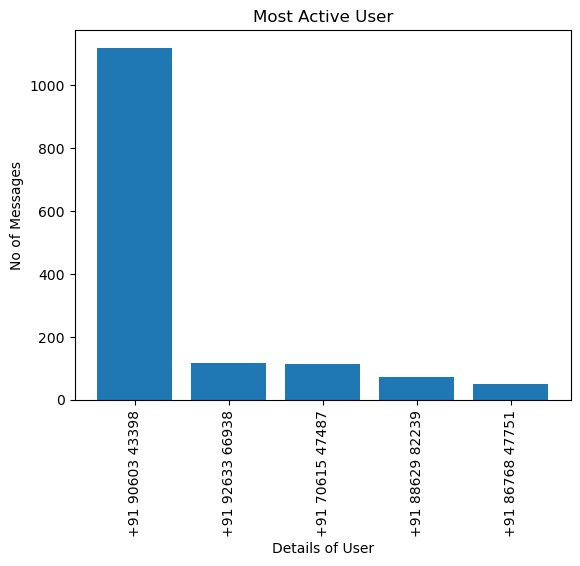

In [23]:
plt.bar(name, count)
plt.xticks(rotation = "vertical")
plt.title("Most Active User")
plt.xlabel("Details of User")
plt.ylabel("No of Messages")
plt.show()

In [24]:
round((df["user"].value_counts()/df.shape[0])*100, 2).reset_index().rename(columns={"user":"Name","count":"Percent"})

,Name,Percent
0,+91 90603 43398,54.37
1,+91 92633 66938,5.73
2,+91 70615 47487,5.58
3,+91 88629 82239,3.50
4,+91 86768 47751,2.38
...,...,...
112,+91 91351 71614,0.05
113,+91 95460 43363,0.05
114,+91 99310 27782,0.05
115,Suraj,0.05


In [25]:
temp = df[df["user"] != "group_notification"]
temp = temp[temp["message"] != "<Media omitted>\n"]

In [26]:
with open("stopwords.txt", "r", encoding="utf-8") as f:
    stop_words = f.read()
print(stop_words)

है
हैं
था
थी
थे
हो
हुआ
हुई
हुए
मैं
हम
तुम
आप
वह
ये
इस
उस
और
या
पर
लेकिन
मगर
क्योंकि
अगर
जब
तब
में
से
तक
के
की
का
को
क्या
कौन
कहाँ
कब
कैसे
क्यों
हाँ
नहीं
अच्छा
ठीक
ओके

hai
hain
tha
thi
the
ho
hua
hui
hue
main
mai
me
hum
tum
aap
wo
woh
ye
yeh
is
us
aur
ya
par
lekin
magar
kyunki
agar
jab
tab
mein
se
tak
ke
ki
ka
ko
kya
kaun
kahan
kab
kaise
kyun
haan
ha
nahi
nhi
acha
-
achha
theek
thik
ok

the
is
am
are
was
were
be
been
being
i
you
he
she
it
we
they
me
him
her
us
them
this
that
these
those
a
an
and
or
but
if
because
as
until
while
of
at
by
for
with
about
against
between
into
through
before
after
above
below
to
from
up
down
in
out
on
off
over
under
again
further
then
once
here
there
when
where
why
how
all
any
both
each
few
more
most
other
some
such
no
nor
not
only
own
same
so
than
too
very
can
will
just
should
now

ok
okay
yes
no
lol
haha
hi
hello
hey


In [27]:
words = []
for message in temp["message"]:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)

In [28]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

,0,1
0,–,126
1,roll,66
2,लिए,62
3,2026,52
4,message,45
5,सभी,43
6,रिजल्ट,42
7,deleted,41
8,बोर्ड,35
9,code,34


In [29]:
pip install emoji

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [30]:
import emoji

In [31]:
emojis = []
for message in df["message"]:
    emojis.extend([c for c in message if c in emoji.EMOJI_DATA])

In [32]:
pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))))

,0,1
0,👇,56
1,🔷,33
2,👨,15
3,💻,15
4,➖,12
...,...,...
59,📝,1
60,🔗,1
61,😘,1
62,✊,1


In [33]:
#

In [34]:
df["month_num"] = df["date"].dt.month

In [35]:
df

,date,user,message,year,month,day,hour,minute,month_num
0,2026-01-30 16:37:00,group_notification,Messages and calls are end-to-end encrypted. O...,2026,January,30,16,37,1
1,2026-01-30 18:33:00,+91 92792 93095,Dled mey Mul praman Patra mang raha abhi tk mi...,2026,January,30,18,33,1
2,2026-01-30 18:53:00,+91 76450 35414,To mat lo admission abhi\n,2026,January,30,18,53,1
3,2026-01-30 18:53:00,+91 76450 35414,Jab mil jayega tab lena\n,2026,January,30,18,53,1
4,2026-01-30 18:58:00,+91 88629 82239,मिलेगा स्कूल से लीजिए जाके नहीं तो स्कूल लिख क...,2026,January,30,18,58,1
...,...,...,...,...,...,...,...,...,...
2055,2026-04-17 11:00:00,+91 90603 43398,<Media omitted>\n,2026,April,17,11,0,4
2056,2026-04-17 18:25:00,+91 88629 82239,<Media omitted>\n,2026,April,17,18,25,4
2057,2026-04-17 19:49:00,+91 82278 91591,Semester 2 ka form ho raha hai kya Bhai......?\n,2026,April,17,19,49,4
2058,2026-04-17 20:55:00,+91 86778 76240,Aabi koi upaye nahi hai\n,2026,April,17,20,55,4


In [36]:
timeline = df.groupby(["year", "month_num", "month"]).count()["message"].reset_index()
timeline

,year,month_num,month,message
0,2026,1,January,31
1,2026,2,February,575
2,2026,3,March,1030
3,2026,4,April,424


In [37]:
time = []
for i in range (timeline.shape[0]):
    time.append(timeline["month"][i] + "-" + str(timeline["year"][i]))

In [38]:
time

['January-2026', 'February-2026', 'March-2026', 'April-2026']

In [39]:
timeline["time"] = time

In [40]:
timeline

,year,month_num,month,message,time
0,2026,1,January,31,January-2026
1,2026,2,February,575,February-2026
2,2026,3,March,1030,March-2026
3,2026,4,April,424,April-2026


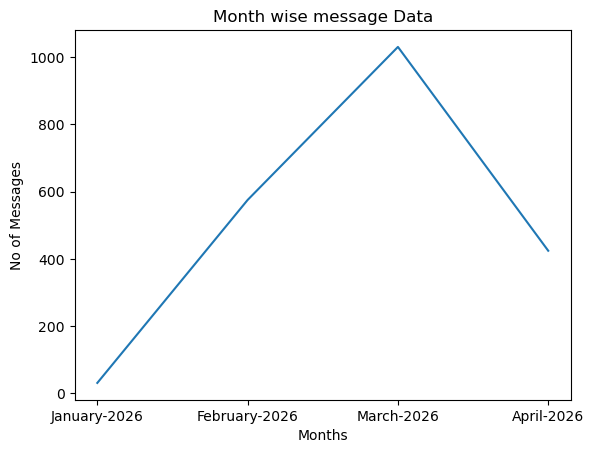

In [41]:
plt.plot(timeline["time"], timeline["message"])
plt.xlabel("Months")
plt.ylabel("No of Messages")
plt.title("Month wise message Data")
plt.show()

In [42]:
df["only_date"] = df["date"].dt.date

In [43]:
daily_timeline = df.groupby("only_date").count()["message"].reset_index()

(array([20485., 20499., 20513., 20527., 20544., 20558.]),
 [Text(20485.0, 0, '2026-02-01'),
  Text(20499.0, 0, '2026-02-15'),
  Text(20513.0, 0, '2026-03-01'),
  Text(20527.0, 0, '2026-03-15'),
  Text(20544.0, 0, '2026-04-01'),
  Text(20558.0, 0, '2026-04-15')])

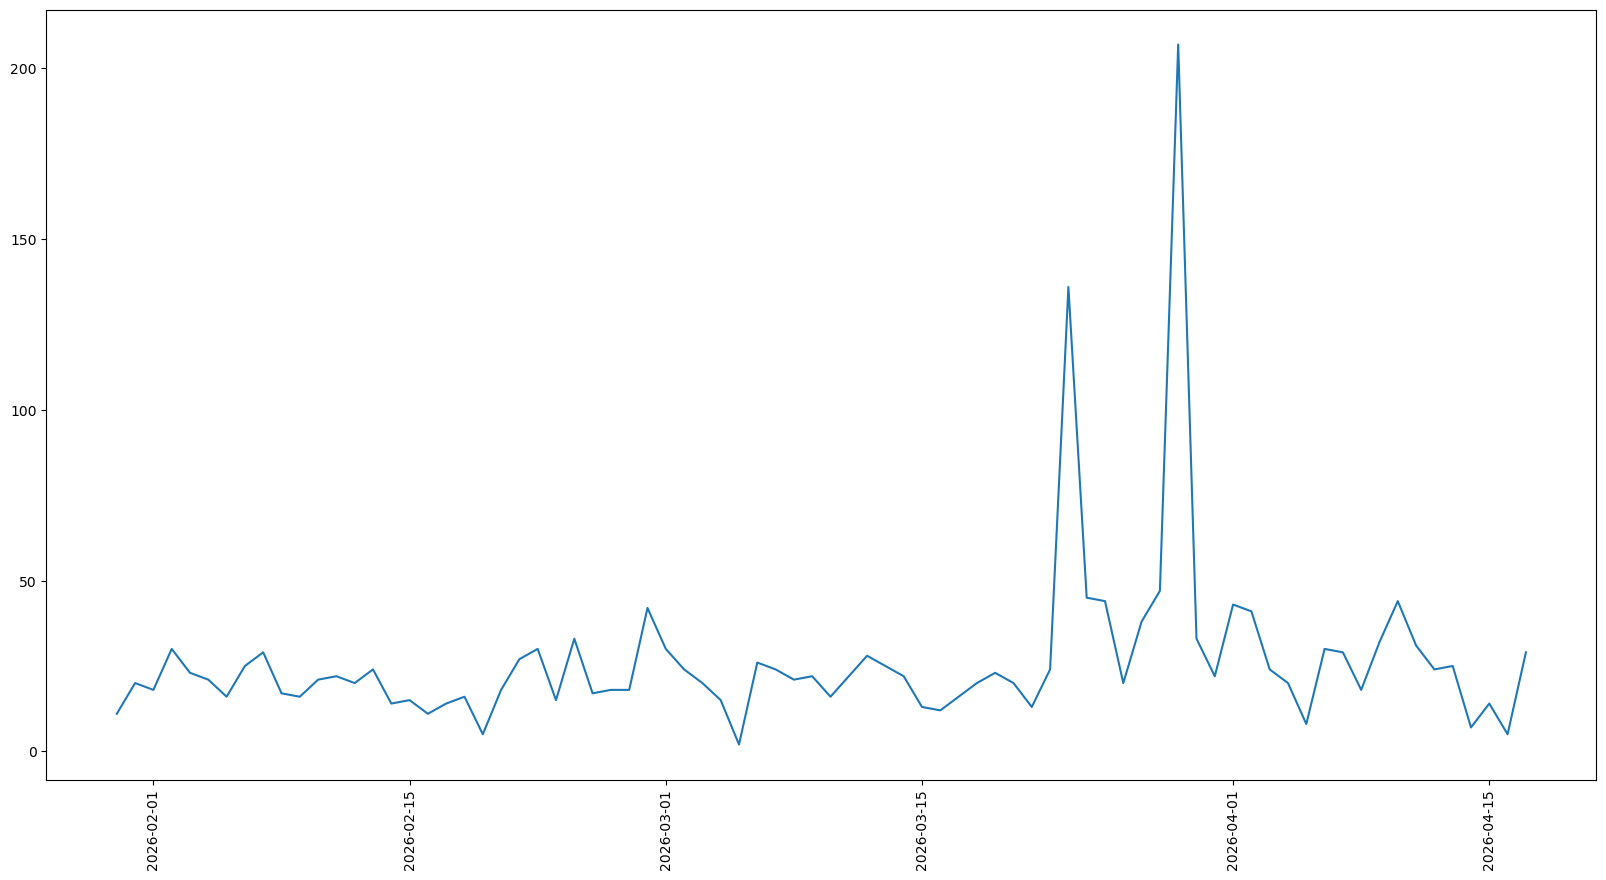

In [44]:
plt.figure(figsize=(20,10))
plt.plot(daily_timeline["only_date"], daily_timeline["message"])
plt.xticks(rotation=90)

In [45]:
df["day_name"] = df["date"].dt.day_name()

In [46]:
df["day_name"].value_counts()

day_name
Sunday       407
Monday       354
Friday       302
Saturday     289
Wednesday    252
Tuesday      246
Thursday     210
Name: count, dtype: int64

In [47]:
df.head()

,date,user,message,year,month,day,hour,minute,month_num,only_date,day_name
0,2026-01-30 16:37:00,group_notification,Messages and calls are end-to-end encrypted. O...,2026,January,30,16,37,1,2026-01-30,Friday
1,2026-01-30 18:33:00,+91 92792 93095,Dled mey Mul praman Patra mang raha abhi tk mi...,2026,January,30,18,33,1,2026-01-30,Friday
2,2026-01-30 18:53:00,+91 76450 35414,To mat lo admission abhi\n,2026,January,30,18,53,1,2026-01-30,Friday
3,2026-01-30 18:53:00,+91 76450 35414,Jab mil jayega tab lena\n,2026,January,30,18,53,1,2026-01-30,Friday
4,2026-01-30 18:58:00,+91 88629 82239,मिलेगा स्कूल से लीजिए जाके नहीं तो स्कूल लिख क...,2026,January,30,18,58,1,2026-01-30,Friday


In [48]:
period = []
for hour in df[["day_name", "hour"]]["hour"]:
    if hour == 23:
        period.append(str(hour) + "-" + str("00"))
    elif hour == 0:
        period.append(str("00") + "-" + str(hour+1))
    else:
        period.append(str(hour) + "-" + str(hour+1))

In [49]:
df["period"]=period

In [50]:
df.drop("Day_Name", axis=1, inplace=True)
df.head()

KeyError: "['Day_Name'] not found in axis"

In [ ]:
import seaborn as sns
plt.figure(figsize=(20, 10))
sns.heatmap(df.pivot_table(index="day_name", columns = "period", values = "message", aggfunc="count").fillna(0))
plt.yticks(rotation=45)
plt.show()